# Some exploratory data anaylisis, to check that the normalisation is working

## Setup

### Imports

In [1]:
import torch
from torch.utils.data import DataLoader

from src import video_transforms as vt
from src.configs import get_avail_splits, get_class_list, set_seed
from src.models import avail_models, norm_vals
from src.run_types import (
    AVAIL_SPLITS,
    SEED,
    CentreCropConfig,
    OG_Sampler,
    RandomCropConfig,
)
from src.utils import plt_display, plt_display_grid
from src.video_dataset import VideoDataset, get_transform, get_wlasl_info
from src.visualise2 import set_thesis_style

In [2]:
set_thesis_style()
set_seed(SEED)

### Model

In [3]:
av_models = avail_models()
print('Available models:')
for idx, m in enumerate(av_models):
    print(f"{idx}: {m}")
    
model_name = "MViTv1_B"
print(f"Chosen model: {model_name}")

Available models:
0: S3D
1: R3D_18
2: R(2+1)D_18
3: Swin3D_T
4: Swin3D_S
5: Swin3D_B
6: MViTv2_S
7: MViTv2_S_e
8: MViTv1_B
9: MViTv2_S_16x4
10: MViTv2_S_16x4_e
11: MViTv2_B_32x3
12: MViTv2_B_32x3_r
Chosen model: MViTv1_B


### Dataset

#### Params

In [4]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)
    
split_name: AVAIL_SPLITS = "asl100"
print(f"Chosen split: {split_name}")

train_info = get_wlasl_info(split_name, set_name="train")
print(train_info)

class_list = get_class_list()
print(len(class_list))

asl100_bottom
asl100
asl300_cutoff_9
asl2000
asl300
asl100_worst
asl100_cutoff_9
asl2000_cutoff_9
asl1000
asl1000_cutoff_9
Chosen split: asl100
{'root': PosixPath('/home/luke/Code/SLR/data/WLASL/WLASL2000'), 'labels': PosixPath('/home/luke/Code/SLR/data/WLASL/preprocessed/labels/asl100'), 'label_suff': 'fixed_frange_bboxes.json', 'set_name': 'train'}
2000


#### Dataloaders

In [5]:
norm_dict = norm_vals(model_name)
print(norm_dict)
num_frames = 16
frame_size = 112
batch_size = 1

train_transform, _, _ = get_transform(
    norm_dict=norm_dict,
    temporal_aug=[OG_Sampler(target_length=num_frames)],
    spatial_aug=[RandomCropConfig(frame_size=frame_size)],
)

test_transform, _, _ = get_transform(
    norm_dict=norm_dict,
    temporal_aug=[OG_Sampler(target_length=num_frames)],
    spatial_aug=[CentreCropConfig(frame_size=frame_size)],
)

train_set = VideoDataset(set_info=train_info, transforms=train_transform)
# same instances as train_set, but centre-cropped instead of randomly cropped
test_set = VideoDataset(set_info=train_info, transforms=test_transform)
# bounding box crop only, no normalisation or resizing:
# NOTE: Unprocessed original bounding box information crops valuable info
bbox_crop_set = VideoDataset(set_info=train_info, item_transforms=vt._crop_frames)
# raw video with no modifications
raw_set = VideoDataset(set_info=train_info)


train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=False,  # not consistent with training, but useful for eda
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

bbox_loader = DataLoader(
    bbox_crop_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

raw_loader = DataLoader(
    raw_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print(len(train_loader))
print(train_set.num_classes)

mean=(0.45, 0.45, 0.45) std=(0.225, 0.225, 0.225)
1442
100


#### Iterators and frame utility function

In [6]:
iter_train_loader = iter(train_loader)
iter_test_loader = iter(test_loader)
iter_bbox_loader = iter(bbox_loader)
iter_raw_loader = iter(raw_loader)

sample_train = next(iter_train_loader)
sample_test = next(iter_test_loader)
sample_bbox = next(iter_bbox_loader)
sample_raw = next(iter_raw_loader)

rf = sample_raw['frames']
print(rf.shape)

torch.Size([1, 63, 3, 256, 256])


In [7]:
def prep_frames_and_label(
    sample: dict[str, int | torch.Tensor],
) -> tuple[torch.Tensor, int]:
    frames = sample['frames']
    assert isinstance(frames, torch.Tensor), f'frames is type: {type(frames)}'
    label_num = sample['label_num']
    assert isinstance(label_num, torch.Tensor), f'label num is type: {type(label_num)}'

    if len(frames.shape) == 5:
        frames = frames.squeeze(dim=0)
    if frames.shape[1] != 3:
        frames = frames.permute(1, 0, 2, 3)  # swap T and C
    return frames, int(label_num.squeeze())

## Looking at what the machine sees: 

### Training

frames: torch.Size([16, 3, 112, 112])
Class: book


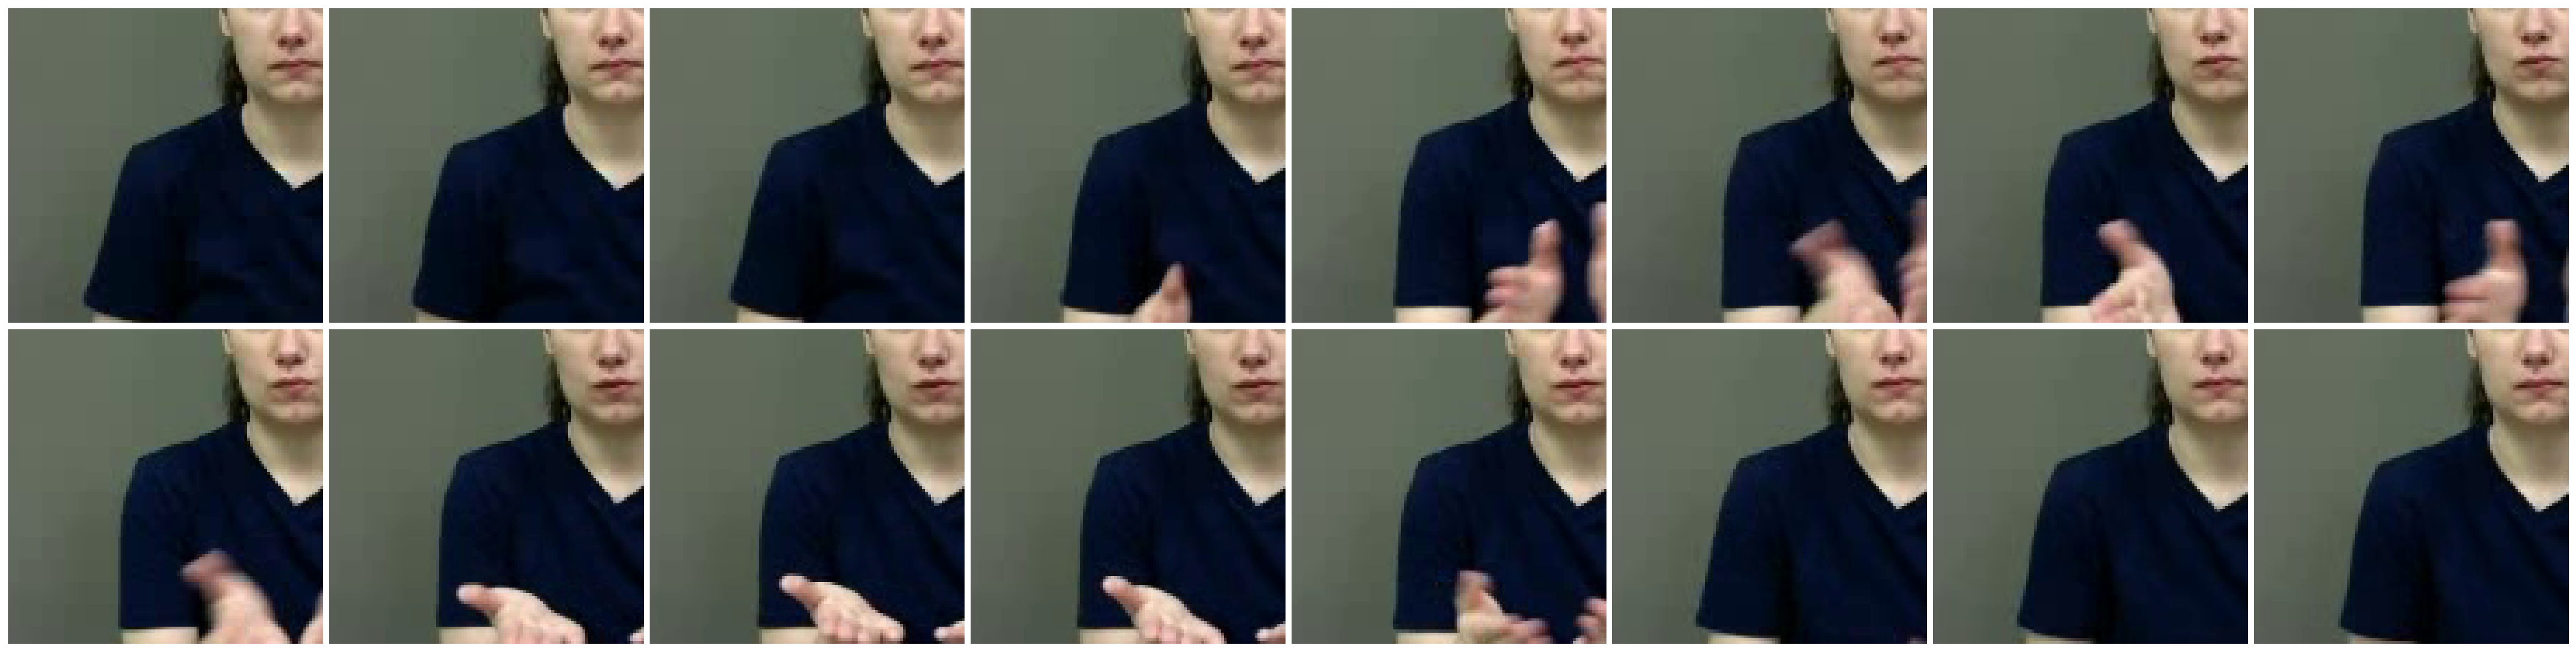

In [8]:
frames_train, label_num = prep_frames_and_label(sample_train)
print(f"frames: {frames_train.shape}")
print(f'Class: {class_list[label_num]}')
# plt_display(frames_train, num_frames)
plt_display_grid(frames_train, num_frames)

### Testing

frames: torch.Size([16, 3, 112, 112])
Class: book


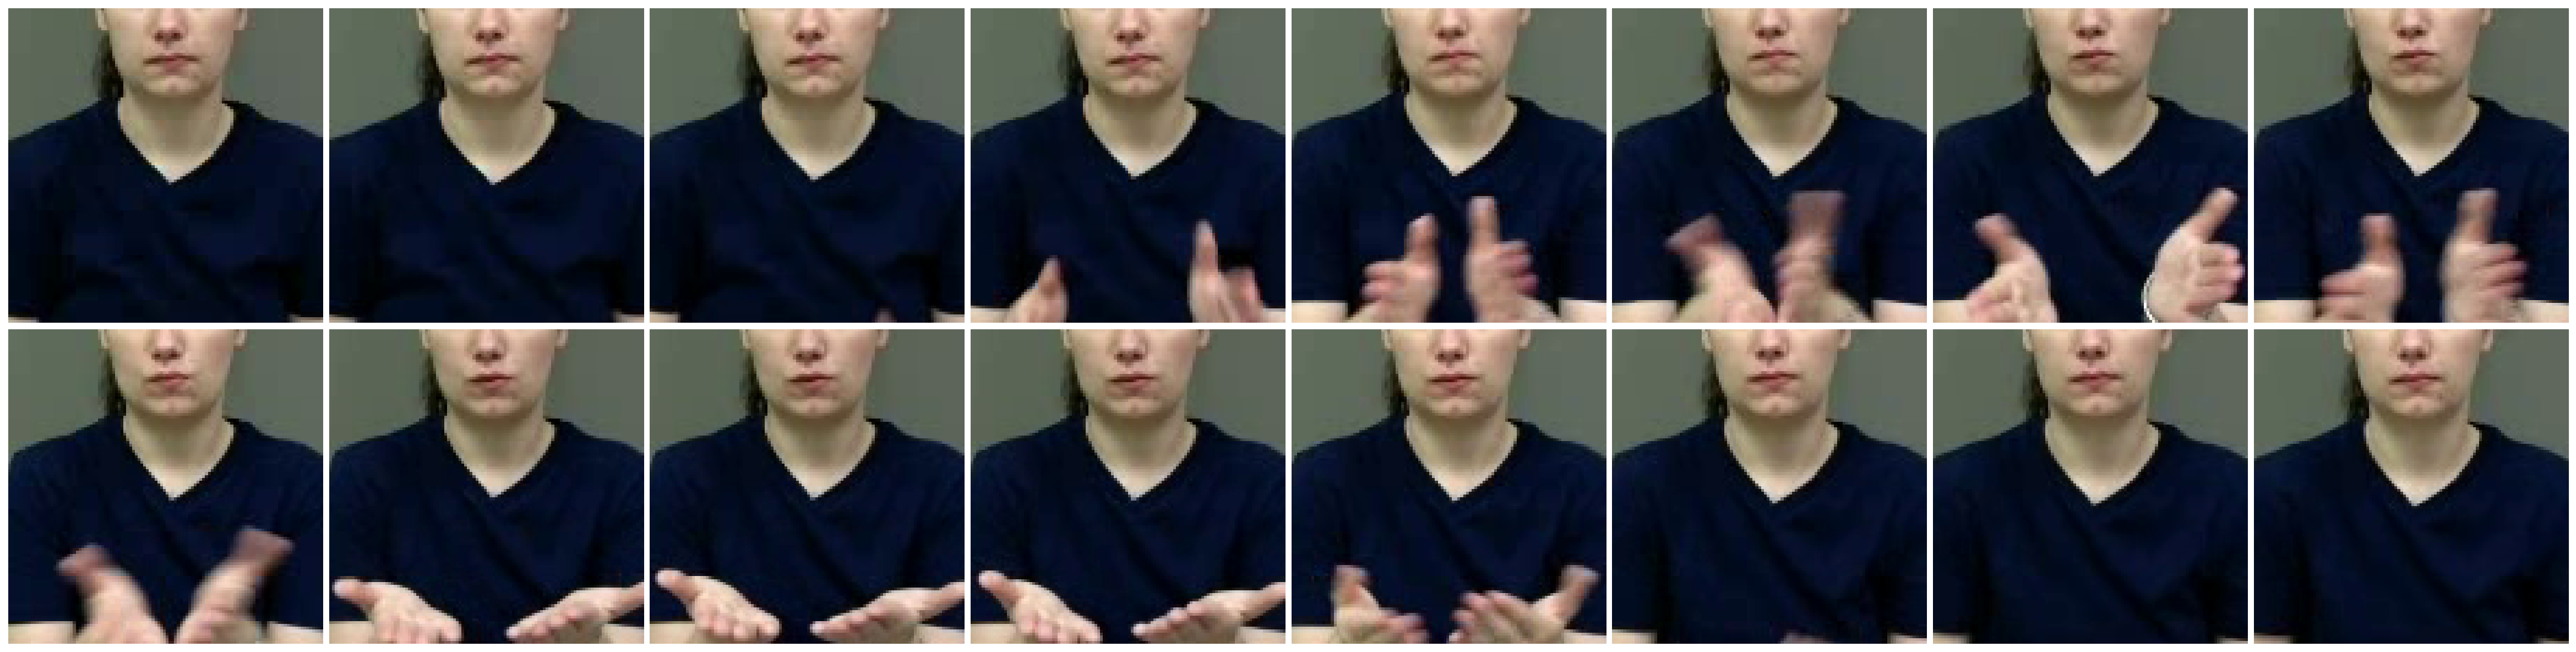

In [9]:
frames_test, label_num = prep_frames_and_label(sample_test)
print(f"frames: {frames_test.shape}")
print(f'Class: {class_list[label_num]}')
# plt_display(frames_test, num_frames)
plt_display_grid(frames_test, num_frames)

### Bbox crop
This will be bad if the original bbox annotations are used. Run [preprocess.py](../../preprocess.py) without the `--no_bbox` flag to use better bboxes. 

frames: torch.Size([63, 3, 240, 119])
Class: book


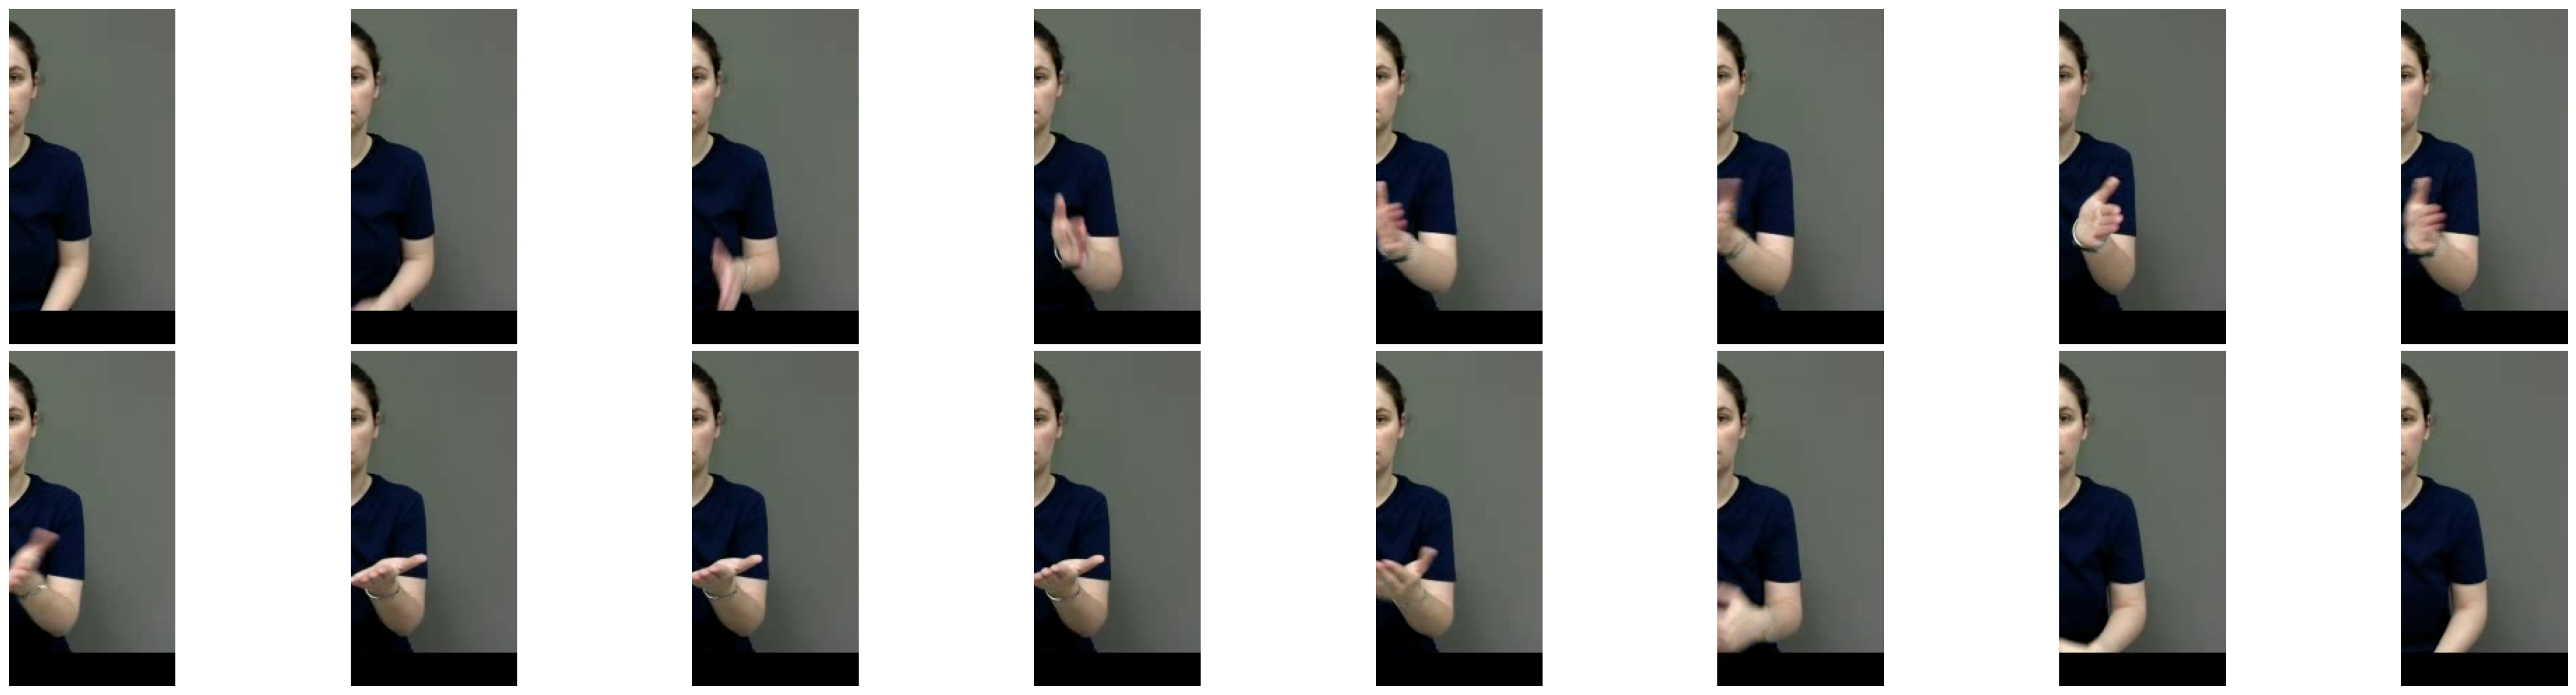

In [10]:
frames_bbox, label_num = prep_frames_and_label(sample_bbox)
print(f"frames: {frames_bbox.shape}")
print(f'Class: {class_list[label_num]}')
# plt_display(frames_bbox, num_frames)
plt_display_grid(frames_bbox, num_frames)

## Looking at the actual video

frames: torch.Size([63, 3, 256, 256])
Class: book


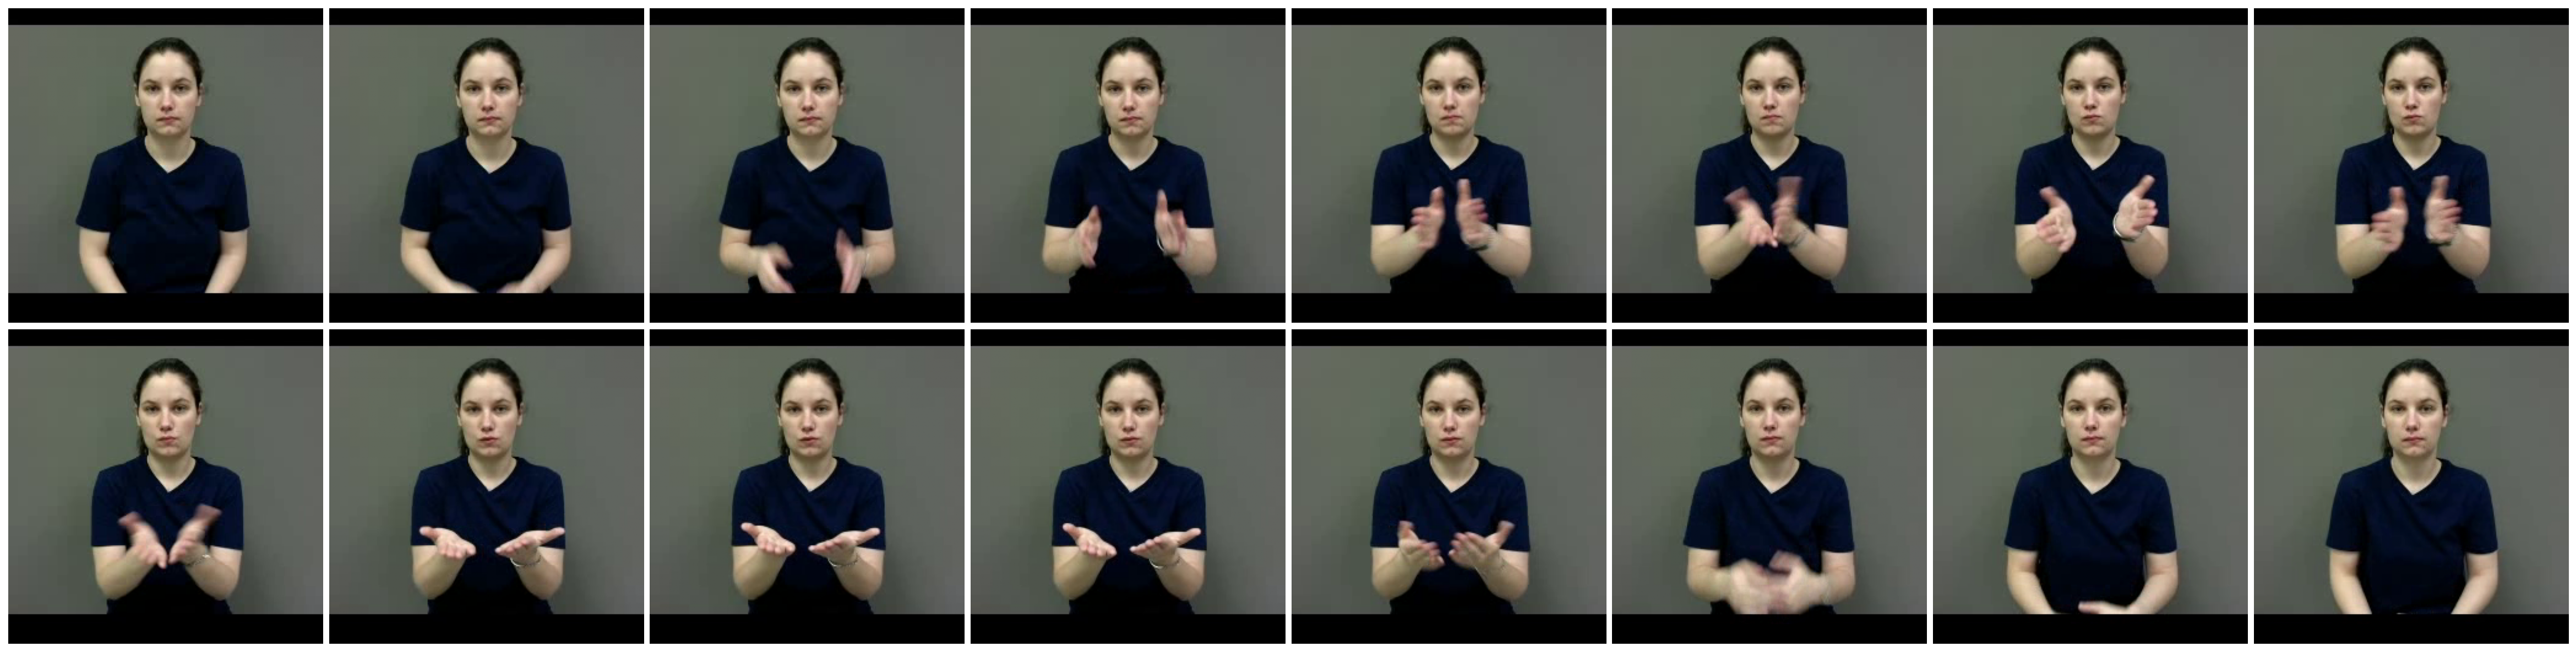

In [12]:
frames_raw, label_num = prep_frames_and_label(sample_raw)
print(f"frames: {frames_raw.shape}")
print(f'Class: {class_list[label_num]}')
# plt_display(frames_raw, num_frames)
plt_display_grid(frames_raw, 16)

## Conclusion:

It seems that during training, significant amounts of information are being lost during cropping. Perhaps this can be remidied. Additionally, perhaps it is worth while testing with crop_bbox, instead of centre crop. 